In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("../data/raw/raw_data.csv")
df.head()

/tmp/ipykernel_6303/1828962278.py:9: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/raw_data.csv")


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


Visualizing TOP 35 columns with most missing data...


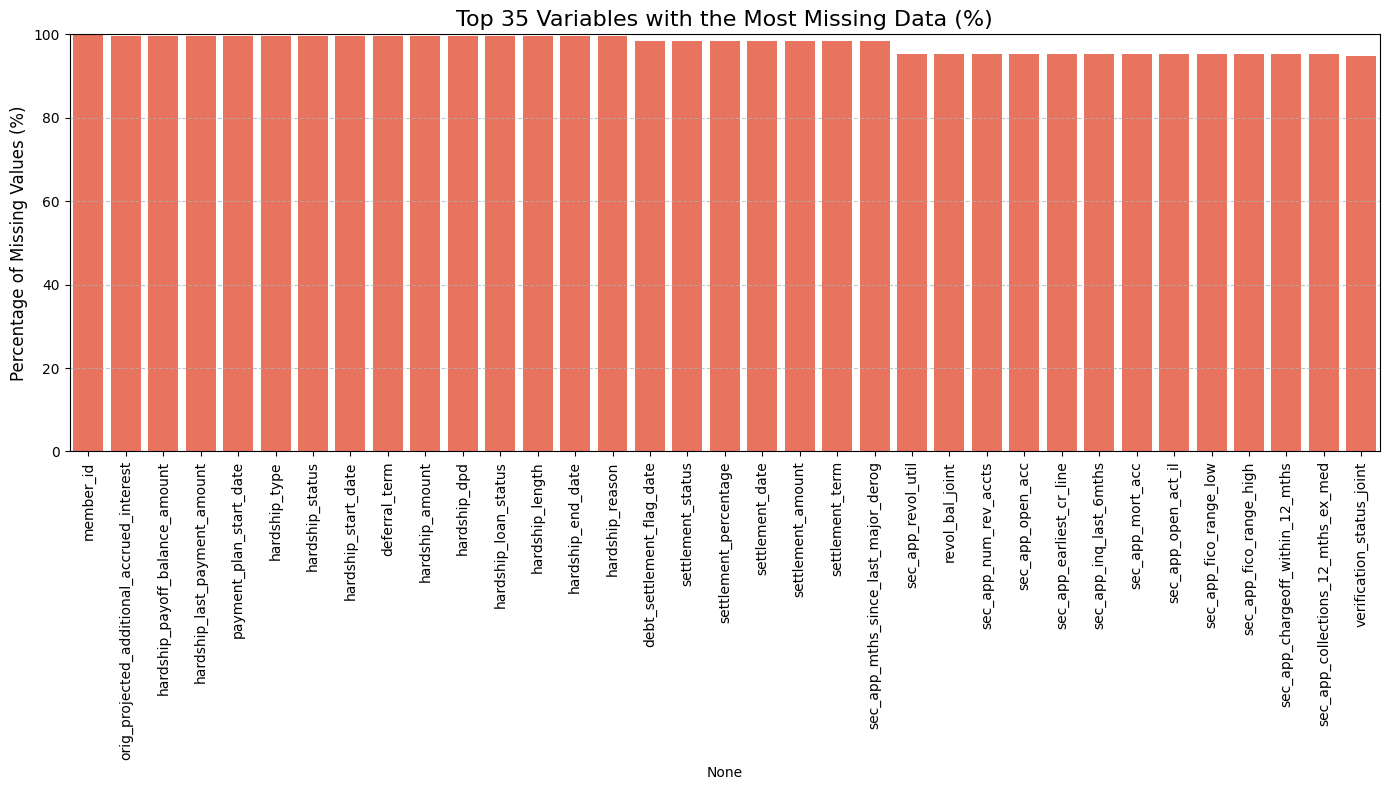

Dropping Data Leakage, irrelevant, and extremely sparse columns...
Applying comprehensive imputation strategies...


/tmp/ipykernel_6303/4224785130.py:113: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_with_nulls = df.select_dtypes(include=['object', 'category']).columns


Imputation complete! Total nulls remaining in dataset: 0
Encoding categorical variables...
Normalizing highly skewed features...
Standardizing numerical features...
Data processing complete! Final dataset shape: (2260668, 111)


,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,issue_d,loan_status,...,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,application_type_Joint App,annual_inc_log
0,68407277,-1.245553,-1.245228,-1.242714,36 months,0.185668,-1.208117,10+ years,Dec-2015,Fully Paid,...,False,False,False,False,False,False,False,False,False,-0.274764
1,68355089,1.050361,1.051143,1.052678,36 months,-0.228228,1.401611,10+ years,Dec-2015,Fully Paid,...,False,False,False,False,False,True,False,False,False,-0.011547
2,68341763,0.538949,0.539629,0.541382,60 months,-0.478635,-0.049207,10+ years,Dec-2015,Fully Paid,...,False,False,False,False,False,False,False,False,True,-0.060790
3,66310712,2.171114,2.172121,2.173177,60 months,0.363643,1.437617,10+ years,Dec-2015,Current,...,False,False,False,False,False,False,False,False,False,0.817389
4,68476807,-0.505637,-0.505165,-0.502967,60 months,1.936446,-0.583504,3 years,Dec-2015,Fully Paid,...,True,False,False,False,False,False,False,False,False,0.735558


In [35]:
# =====================================================================
# STEP 0: VISUALIZE INITIAL MISSING DATA
# =====================================================================
print("Visualizing TOP 35 columns with most missing data...")

# 1. Calculate the percentage of missing values per column
missing_percent = (df.isnull().sum() / len(df)) * 100

# 2. Filter only those with missing values (> 0%) and sort descending
missing_cols = missing_percent[missing_percent > 0].sort_values(ascending=False)

# 3. Take only the top 35 columns (keep it as a Pandas Series to have index and values)
top_missing_cols = missing_cols.head(35)

# 4. Plot using Seaborn (Larger bar = more missing data)
plt.figure(figsize=(14, 8))
sns.barplot(x=top_missing_cols.index, y=top_missing_cols.values, color="tomato")

# Visual adjustments for readability
plt.title("Top 35 Variables with the Most Missing Data (%)", fontsize=16)
plt.ylabel("Percentage of Missing Values (%)", fontsize=12)
plt.xticks(rotation=90, fontsize=10) # Rotate labels so they don't overlap
plt.ylim(0, 100) # Set Y-axis from 0 to 100%
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add subtle horizontal grid lines

plt.tight_layout()
plt.show()
# =====================================================================
# STEP 1: DROP DATA LEAKAGE, IRRELEVANT & HIGH-NULL COLUMNS
# =====================================================================
print("Dropping Data Leakage, irrelevant, and extremely sparse columns...")

columns_to_drop = [
    # 1. Identifiers and text
    'member_id', 'url', 'desc', 'title', 'emp_title',
    
    # 2. Hardship flags and details (Data Leakage)
    'hardship_reason', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 
    'payment_plan_start_date', 'hardship_type', 'hardship_status', 'hardship_start_date', 
    'deferral_term', 'hardship_amount', 'hardship_dpd', 'hardship_loan_status', 
    'hardship_length', 'hardship_end_date', 'hardship_flag',
    
    # 3. Settlement flags and details (Data Leakage)
    'settlement_status', 'debt_settlement_flag_date', 'settlement_term', 
    'settlement_percentage', 'settlement_date', 'settlement_amount', 'debt_settlement_flag',
    
    # 4. Joint App features (Too many nulls, highly imbalanced)
    'sec_app_mths_since_last_major_derog', 'sec_app_revol_util', 'sec_app_inq_last_6mths', 
    'sec_app_num_rev_accts', 'sec_app_open_acc', 'sec_app_earliest_cr_line', 
    'sec_app_fico_range_high', 'sec_app_mort_acc', 'sec_app_open_act_il', 
    'sec_app_fico_range_low', 'sec_app_collections_12_mths_ex_med', 
    'sec_app_chargeoff_within_12_mths', 'revol_bal_joint', 'verification_status_joint', 
    'dti_joint', 'annual_inc_joint',
    
    # 5. Post-origination metrics / Recoveries (Data Leakage)
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 
    'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
    
    # 6. High missingness without business value (>40% nulls)
    'il_util', 'mths_since_rcnt_il', 'all_util', 'open_acc_6m', 'total_cu_tl', 'inq_last_12m'
]

df = df.drop(columns=columns_to_drop, errors='ignore')
df = df.dropna(subset=['loan_status'])

# =====================================================================
# STEP 2: DATA IMPUTATION (CONSTANT, MEDIAN, MODE)
# =====================================================================
print("Applying comprehensive imputation strategies...")

# Utility function for visual benchmarking (kept for your EDA process)
def compare_imputation_strategies(dataframe, feature, constant_val=-999):
    original = dataframe[feature].dropna()
    mean_imputed = dataframe[feature].fillna(dataframe[feature].mean())
    median_imputed = dataframe[feature].fillna(dataframe[feature].median())
    constant_imputed = dataframe[feature].fillna(constant_val)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Imputation Strategy Comparison for: {feature}', fontsize=16)
    sns.histplot(original, kde=True, bins=40, color="blue", ax=axes[0, 0]).set_title('1. Original Distribution')
    sns.histplot(mean_imputed, kde=True, bins=40, color="green", ax=axes[0, 1]).set_title('2. Mean Imputation')
    sns.histplot(median_imputed, kde=True, bins=40, color="orange", ax=axes[1, 0]).set_title('3. Median Imputation')
    sns.histplot(constant_imputed, kde=True, bins=40, color="red", ax=axes[1, 1]).set_title(f'4. Constant Imputation ({constant_val})')
    plt.tight_layout()
    plt.show()

# 2.1 Impute 'Informative Nulls' with a Constant (Fixed Value)
# NaN in 'months since...' usually means the event NEVER happened. 
# We impute with 999 so the model treats it as a distinct, safe category.
informative_null_cols = [
    'mths_since_last_delinq', 
    'mths_since_last_record', 
    'mths_since_recent_bc_dlq', 
    'mths_since_last_major_derog',
    'mths_since_recent_revol_delinq',
    'mths_since_recent_inq'
]

for col in informative_null_cols:
    if col in df.columns:
        df[col] = df[col].fillna(999)

# 2.2 Dynamically impute ALL remaining numerical features with Median
# We find all float/int columns that still have missing values
num_cols_with_nulls = df.select_dtypes(include=['int64', 'float64']).columns
num_cols_with_nulls = df[num_cols_with_nulls].columns[df[num_cols_with_nulls].isnull().any()].tolist()

for col in num_cols_with_nulls:
    df[col] = df[col].fillna(df[col].median())

# 2.3 Dynamically impute ALL remaining categorical features with Mode
# We find all object/category columns that still have missing values
cat_cols_with_nulls = df.select_dtypes(include=['object', 'category']).columns
cat_cols_with_nulls = df[cat_cols_with_nulls].columns[df[cat_cols_with_nulls].isnull().any()].tolist()

for col in cat_cols_with_nulls:
    # Mode returns a Series, so we extract the first value [0]
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Imputation complete! Total nulls remaining in dataset: {df.isnull().sum().sum()}")

# =====================================================================
# STEP 3: ENCODING CATEGORICAL VARIABLES
# =====================================================================
print("Encoding categorical variables...")

# 3.1 Ordinal Encoding for Risk Grades
grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
if 'grade' in df.columns:
    df['grade_encoded'] = df['grade'].map(grade_mapping)
    df = df.drop(columns=['grade', 'sub_grade'], errors='ignore')

# 3.2 One-Hot Encoding for Nominal Variables (drop_first=True avoids Dummy Trap)
nominal_columns = ['home_ownership', 'verification_status', 'purpose', 'application_type']
nominal_columns_exist = [col for col in nominal_columns if col in df.columns]
df = pd.get_dummies(df, columns=nominal_columns_exist, drop_first=True)

# =====================================================================
# STEP 4: NORMALIZING SKEWED DATA
# =====================================================================
print("Normalizing highly skewed features...")
# Using log1p to handle right-skewed income data safely (handles zeros)
if 'annual_inc' in df.columns:
    df['annual_inc_log'] = np.log1p(df['annual_inc'])
    df = df.drop(columns=['annual_inc'])

# =====================================================================
# STEP 5: STANDARDIZING NUMERICAL DATA
# =====================================================================
print("Standardizing numerical features...")

# Select only numerical columns (int64, float64), ignoring booleans from get_dummies
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Ensure we don't scale the target variable if it's already numeric
numerical_cols = [col for col in numerical_cols if col != 'loan_status']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Data processing complete! Final dataset shape:", df.shape)
display(df.head())